In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import json
import numpy as np
from sources.MKP import MultipleKnapsackProblem
from sources.MKPsolver import MKPQAOASolver
from matplotlib import pyplot as plt

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

In [ ]:

# Load instances
with open('data/final_knapsack_data.json', 'r') as f:
    instances = json.load(f)

In [4]:
# Load results

with open('results/QAOA/standard_p=5_s=1024.json', 'r') as f:
    results_standard = json.load(f)
with open('results/QAOA/no_slack_p=5_s=1024.json', 'r') as f:
    results_no_slack = json.load(f)
with open('results/QAOA/cont_slack_p=5_s=1024.json', 'r') as f:
    results_cont_slack = json.load(f)
with open('results/QAOA/unbalanced_p=5_s=1024.json', 'r') as f:
    results_unbalanced_penalization = json.load(f)    

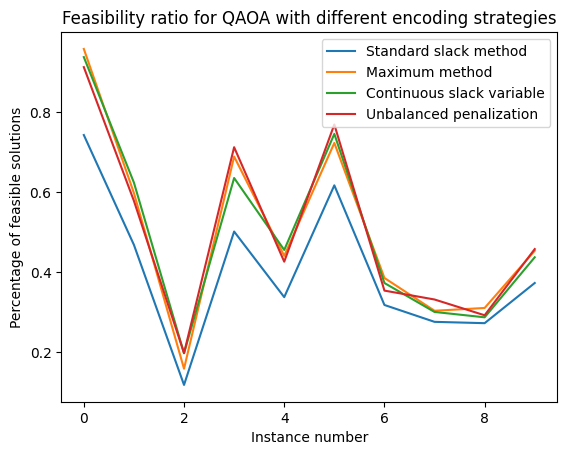

In [8]:
# PLOTTING feasibility

insts = [i for i in range(10)]



feasibility_ratios_standard = [np.mean([results_standard[str(i)][str(r)]["feasibility"] for r in range(20)]) for i in insts]
feasibility_ratios_no_slack = [np.mean([results_no_slack[str(i)][str(r)]["feasibility"] for r in range(20)]) for i in insts]
feasibility_ratios_cont_slack = [np.mean([results_cont_slack[str(i)][str(r)]["feasibility"] for r in range(20)]) for i in insts]
feasibility_ratios_unbalanced_penalization = [np.mean([results_unbalanced_penalization[str(i)][str(r)]["feasibility"] for r in range(20)]) for i in insts]

plt.plot(insts, feasibility_ratios_standard, label="Standard slack method")
plt.plot(insts, feasibility_ratios_no_slack, label="Maximum method")
plt.plot(insts, feasibility_ratios_cont_slack, label="Continuous slack variable")
plt.plot(insts, feasibility_ratios_unbalanced_penalization, label="Unbalanced penalization")
plt.xlabel("Instance number")
plt.ylabel("Percentage of feasible solutions")
plt.title("Feasibility ratio for QAOA with different encoding strategies")
plt.legend()
plt.savefig("Plots/encoding_variants_feasibility.pdf")



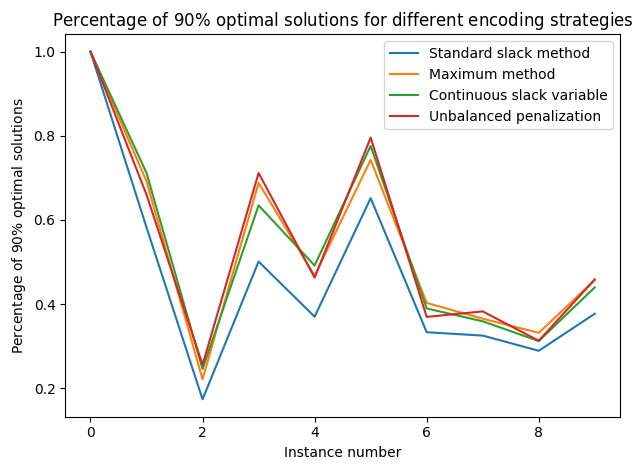

In [9]:
# PLOTTING 90% optimality

insts = [i for i in range(10)]



optimality_ratios_standard = [np.mean([results_standard[str(i)][str(r)]["opt_90_percentage"] for r in range(20)]) for i in insts]
optimality_ratios_no_slack = [np.mean([results_no_slack[str(i)][str(r)]["opt_90_percentage"] for r in range(20)]) for i in insts]
optimality_ratios_cont_slack = [np.mean([results_cont_slack[str(i)][str(r)]["opt_90_percentage"] for r in range(20)]) for i in insts]
optimality_ratios_unbalanced_penalization = [np.mean([results_unbalanced_penalization[str(i)][str(r)]["opt_90_percentage"] for r in range(20)]) for i in insts]

plt.plot(insts, optimality_ratios_standard, label="Standard slack method")
plt.plot(insts, optimality_ratios_no_slack, label="Maximum method")
plt.plot(insts, optimality_ratios_cont_slack, label="Continuous slack variable")
plt.plot(insts, optimality_ratios_unbalanced_penalization, label="Unbalanced penalization")
plt.xlabel("Instance number")
plt.ylabel("Percentage of $90\%$ optimal solutions")
plt.title("Percentage of $90\%$ optimal solutions for different encoding strategies")
plt.legend()
plt.tight_layout()
plt.savefig("Plots/encoding_variants_optimality.pdf")
